In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import gzip


In [22]:
class_labels = pd.read_csv("data/class.tsv",header=None,names=["Class"])["Class"]
columns_df = pd.read_csv("data/columns.tsv.gz",sep="\t", comment="#")
# Extract IDs for XBP1 and GATA3
gene_ids = (columns_df.set_index("GeneSymbol").loc[["XBP1", "GATA3"]]["ID"].astype(str).tolist())

In [23]:
with gzip.open("data/filtered.tsv.gz", "rt") as f:
    expression_df = pd.read_csv(f, sep="\t")
expression_df.columns = expression_df.columns.str.strip()

selected_expr = expression_df[gene_ids].copy()
selected_expr.columns = ["XBP1", "GATA3"]

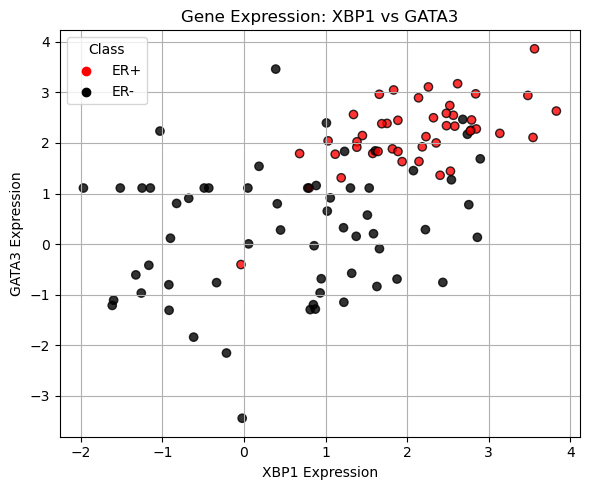

In [25]:
color_map = {1: "red", 0: "black"}
colors = class_labels.map(color_map)

plt.figure(figsize=(6, 5))
plt.scatter(
    selected_expr["XBP1"],
    selected_expr["GATA3"],
    c=colors,
    alpha=0.8,
    edgecolor='k'
)
plt.xlabel("XBP1 Expression")
plt.ylabel("GATA3 Expression")
plt.title("Gene Expression: XBP1 vs GATA3")
plt.grid(True)

for cls, col in color_map.items():
    label = "ER+" if cls == 1 else "ER-"
    plt.scatter([], [], c=col, label=label)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [26]:
pca = PCA(n_components=1)
pc1 = pca.fit_transform(selected_expr)

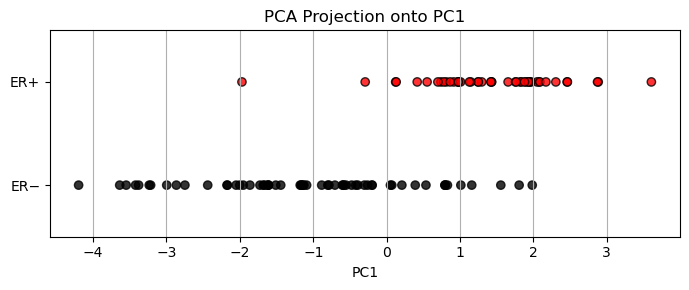

In [28]:
y_offsets = class_labels.values  # 0 or 1
plt.figure(figsize=(7, 3))
plt.scatter(pc1,y_offsets,c=colors,alpha=0.8,edgecolor='k')
plt.yticks([0, 1], ["ER−", "ER+"])
plt.ylim(-0.5, 1.5)
plt.xlabel("PC1")
plt.title("PCA Projection onto PC1")
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()